In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("/workspaces/Sentiment-analysis-on-social-media/social_media_sentiment_train.csv")

In [3]:
data.sample()

,text,label
4240,omg this is great ✨,Positive


In [4]:
data.isnull().sum()

text     0
label    0
dtype: int64

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    10000 non-null  str  
 1   label   10000 non-null  str  
dtypes: str(2)
memory usage: 156.4 KB


In [6]:
data['label'].value_counts()

label
Positive     2930
Negative     2850
Sarcastic    2702
Neutral      1518
Name: count, dtype: int64

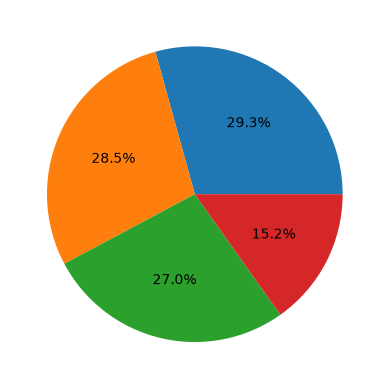

In [7]:
plt.pie(data['label'].value_counts(), autopct='%1.1f%%')
plt.show()

In [8]:
data.columns

Index(['text', 'label'], dtype='str')

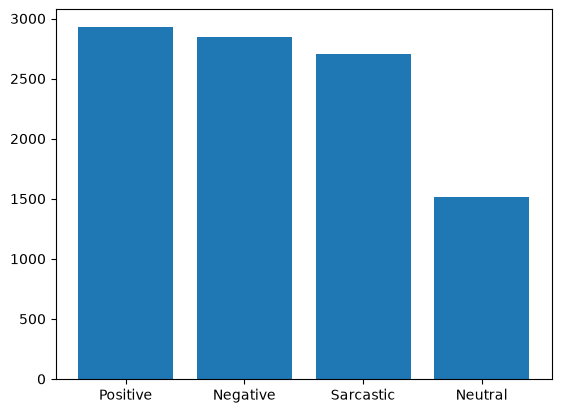

In [9]:
value=data['label'].value_counts()
plt.bar(value.index, value.values)
plt.show()

In [10]:
data['text']

0                tbh thissss is lit 🔥
1             omg it was normalllll 🤷
2         tbh thisssss is fatnastic 🔥
3                 ngl this is trash 😡
4               idk this is perfect 🥳
                    ...              
9995             tbh it was aevrage 🤷
9996         bro this is amazingggg 😍
9997        bro thisss is fantastic 😁
9998    highkey this is pefrecttttt 😄
9999         highkey it was regualr 🫤
Name: text, Length: 10000, dtype: str

In [12]:
# preprocess data
# lowercase
# stemming
# split data
data['text'] = data['text'].str.lower()

In [13]:
import re

In [16]:
def remove_repeated(text):
    return re.sub(r'(.)\{2,}', r'\1', text)

data["text"]=data["text"].apply(remove_repeated)
data['text']

0               tbh this is lit 🔥
1             omg it was normal 🤷
2         tbh this is fatnastic 🔥
3             ngl this is trash 😡
4           idk this is perfect 🥳
                  ...            
9995         tbh it was aevrage 🤷
9996        bro this is amazing 😍
9997      bro this is fantastic 😁
9998    highkey this is pefrect 😄
9999     highkey it was regualr 🫤
Name: text, Length: 10000, dtype: str

In [17]:
pip install textblob

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.0/625.0 kB 12.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.3/801.3 kB 20.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [textblob]4/5 [textblob]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
from textblob import TextBlob
data["text"] = data ["text"].apply(lambda x: str(TextBlob(x).correct))